# EDA inicial - Spotify Tracks

Esta primera parte explora la estructura y la calidad general del conjunto de datos. No incluye transformaciones avanzadas ni modelamiento.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga de los datos

In [3]:
DATA_PATH = Path("../data/raw/Spotify_Tracks_Dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontro el archivo: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 114,000
Columnas: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Estructura y tipos de datos

In [4]:
resumen_columnas = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_no_nulos": df.notna().sum(),
    "valores_unicos": df.nunique(dropna=True)
})
resumen_columnas

,tipo,valores_no_nulos,valores_unicos
Unnamed: 0,int64,114000,114000
track_id,object,114000,89741
artists,object,113999,31437
album_name,object,113999,46589
track_name,object,113999,73608
popularity,int64,114000,101
duration_ms,int64,114000,50697
explicit,bool,114000,2
danceability,float64,114000,1174
energy,float64,114000,2083


## 3. Calidad de datos

In [5]:
calidad = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(3),
})
calidad[calidad["nulos"] > 0]

,nulos,porcentaje_nulos
artists,1,0.001
album_name,1,0.001
track_name,1,0.001


In [6]:
print(f"Filas duplicadas completas: {df.duplicated().sum():,}")
print(f"IDs de canciones repetidos: {df['track_id'].duplicated().sum():,}")
print(f"Generos distintos: {df['track_genre'].nunique()}")
print(f"Canciones explicitas: {df['explicit'].mean() * 100:.2f}%")

Filas duplicadas completas: 0
IDs de canciones repetidos: 24,259
Generos distintos: 114
Canciones explicitas: 8.55%


**Observacion:** `Unnamed: 0` parece ser un indice guardado durante una exportacion. Para este EDA se crea una copia sin esa columna, conservando intacto el archivo original.

In [7]:
df_eda = df.drop(columns=["Unnamed: 0"], errors="ignore").copy()
df_eda.shape

(114000, 20)

## 4. Estadisticas descriptivas

In [8]:
variables_principales = [
    "popularity", "duration_ms", "danceability", "energy",
    "loudness", "acousticness", "valence", "tempo"
]
df_eda[variables_principales].describe().round(2)

,popularity,duration_ms,danceability,energy,loudness,acousticness,valence,tempo
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,33.24,228029.15,0.57,0.64,-8.26,0.31,0.47,122.15
std,22.31,107297.71,0.17,0.25,5.03,0.33,0.26,29.98
min,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00
25%,17.00,174066.00,0.46,0.47,-10.01,0.02,0.26,99.22
50%,35.00,212906.00,0.58,0.68,-7.00,0.17,0.46,122.02
75%,50.00,261506.00,0.70,0.85,-5.00,0.60,0.68,140.07
max,100.00,5237295.00,0.98,1.00,4.53,1.00,1.00,243.37


## 5. Visualizaciones simples

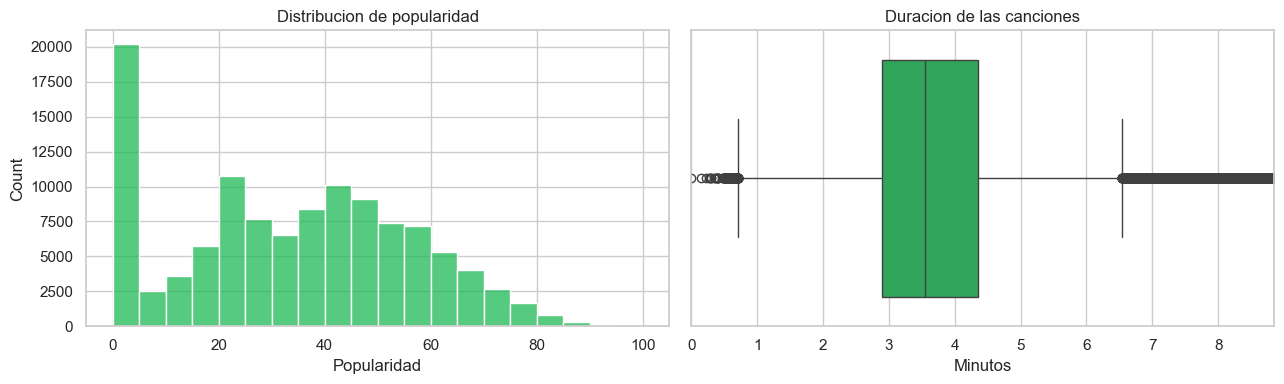

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df_eda, x="popularity", bins=20, ax=axes[0], color="#1DB954")
axes[0].set_title("Distribucion de popularidad")
axes[0].set_xlabel("Popularidad")

duration_minutes = df_eda["duration_ms"] / 60000
sns.boxplot(x=duration_minutes, ax=axes[1], color="#1DB954")
axes[1].set_title("Duracion de las canciones")
axes[1].set_xlabel("Minutos")
axes[1].set_xlim(0, duration_minutes.quantile(0.99))

plt.tight_layout()
plt.show()

## 6. Conclusiones iniciales

- El dataset tiene 114.000 registros y 21 columnas.
- Hay solamente 3 valores nulos, distribuidos en `artists`, `album_name` y `track_name`.
- No hay filas completamente duplicadas, pero existen IDs de canciones repetidos.
- La variable `Unnamed: 0` es un indice exportado y se excluye de la copia usada para analizar.
- La duracion presenta valores extremos, incluidos registros de cero milisegundos.
- En la siguiente etapa se deben estudiar duplicados por `track_id`, valores extremos y reglas de limpieza.